### Ferritin Prediction

### Dataset Examination (Veri Setinin İncelenmesi)

In [ ]:
#Kutuphanelerin Dahil Edilmesi
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
%matplotlib inline

from joblib import dump, load

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, validation_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, auc, roc_curve
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import KNNImputer

import tensorflow as tf
from tensorflow import keras

from keras import metrics
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization, Input, ReLU, LeakyReLU, PReLU
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanSquaredError, RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.activations import linear

from keras_tuner import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters

import warnings
warnings.filterwarnings("ignore")

random.seed(17)
np.random.seed(17)
tf.random.set_seed(17)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [ ]:
#Veri Setinin Okunmasi
df = pd.read_excel("ferritin_data.xlsx")
df.drop('No', axis=1, inplace=True)
#df.drop('Ferritin Level', axis=1, inplace=True)
data = df.copy()

In [ ]:
# Veri Setine Genel Bakis icin Fonksiyonlar
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")

def plot_target_summary_with_cat(dataframe, target, categorical_col):
    mean_values = dataframe.groupby(categorical_col)[target].mean().reset_index()
    fig = px.bar(mean_values, x=categorical_col, y=target, title=f'{categorical_col} - {target} (Mean)',
                 color=categorical_col, color_discrete_sequence=px.colors.qualitative.Set2)
    fig.update_layout(bargap=0.2)
    fig.show()

def correlation_matrix(df, cols):
    fig = plt.gcf()
    fig.set_size_inches(10, 8)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    fig = sns.heatmap(df[cols].corr(), annot=True, linewidths=0.5, annot_kws={'size': 12}, linecolor='w', cmap='RdBu')
    plt.show(block=True)

def grab_col_names(dataframe, cat_th=15, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optinal
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
        Return olan 3 liste toplamı toplam değişken sayısına eşittir: cat_cols + num_cols + cat_but_car = değişken sayısı

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # print(f"Observations: {dataframe.shape[0]}")
    # print(f"Variables: {dataframe.shape[1]}")
    # print(f'cat_cols: {len(cat_cols)}')
    # print(f'num_cols: {len(num_cols)}')
    # print(f'cat_but_car: {len(cat_but_car)}')
    # print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

In [ ]:
#Veri Setindeki ilk 10 veriye goz atma
df.head(n=10)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1
5,47,Kadın,7.20000,61.60000,25.70000,6.60000,10.70000,17.30000,18.70000,2.70000,1
6,47,Kadın,6.50000,66.10000,24.80000,5.45000,9.90000,17.30000,23.60000,2.80000,1
7,31,Kadın,8.50000,64.30000,30.50000,7.27000,9.70000,17.90000,19.10000,2.90000,1
8,29,Kadın,8.20000,65.30000,31.40000,7.87000,9.60000,17.00000,20.30000,3.00000,1
9,44,Kadın,5.80000,59.70000,22.40000,6.67000,9.80000,15.50000,21.20000,3.00000,1


In [ ]:
#Veri Setindeki son 10 veriye goz atma
df.tail(n=10)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
7190,81,Kadın,12.00000,95.00000,38.30000,9.17000,11.80000,29.80000,13.40000,391.00000,0
7191,53,Erkek,14.60000,89.20000,44.40000,8.87000,9.00000,29.30000,12.00000,394.00000,0
7192,55,Erkek,14.90000,94.20000,45.80000,6.03000,12.20000,30.70000,13.90000,395.00000,0
7193,45,Erkek,15.30000,91.20000,44.70000,7.71000,10.60000,31.20000,11.80000,395.00000,0
7194,54,Erkek,15.00000,89.20000,44.00000,9.23000,10.00000,30.40000,12.40000,396.00000,0
7195,67,Kadın,14.90000,87.60000,44.70000,8.60000,10.90000,29.20000,11.70000,397.00000,0
7196,60,Erkek,16.90000,89.90000,49.90000,7.61000,10.50000,30.50000,13.20000,398.00000,0
7197,74,Erkek,13.50000,93.40000,40.80000,7.41000,10.50000,30.90000,13.20000,398.00000,0
7198,72,Erkek,12.10000,96.10000,37.30000,7.14000,9.50000,31.20000,12.90000,399.00000,0
7199,28,Erkek,16.30000,82.10000,48.60000,6.64000,10.40000,27.50000,12.30000,399.00000,0


In [ ]:
#Veri setinin satir, sutun sayısı
print("################ Shape ################ ")
print(df.shape)
print("Gozlem (n) sayisi:", len(df.index))
print("Degisken (variable) sayisi:",len(df.columns))

################ Shape ################ 
(7200, 11)
Gozlem (n) sayisi: 7200
Degisken (variable) sayisi: 11


In [ ]:
#Verilen Tipleri (Data Types)
print("################ Data Types ################")
df['Yaş'] = df['Yaş'].astype('float64')
df.dtypes

################ Data Types ################


Yaş                   float64
Cinsiyet               object
HGB (12-16)           float64
MCV (81-101)          float64
HCT (36-44)           float64
WBC (4.5-10)          float64
MPV (9-12)            float64
MCH (27-35)           float64
RDW-CV (11.5-14.5)    float64
Ferritin (30-400)     float64
Ferritin Level          int64
dtype: object

In [ ]:
# Eksik verilere (Missing Value) bakma
print("################ Missing Values ################")
df.isnull().sum()

################ Missing Values ################


Yaş                   0
Cinsiyet              0
HGB (12-16)           0
MCV (81-101)          0
HCT (36-44)           0
WBC (4.5-10)          0
MPV (9-12)            0
MCH (27-35)           0
RDW-CV (11.5-14.5)    0
Ferritin (30-400)     0
Ferritin Level        0
dtype: int64

In [ ]:
#Kategorik ve Numerik Degiskenleri Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

In [ ]:
# Toplam Degisken Sayisi
print("Toplam degisken sayisi:", len(cat_cols+num_cols+cat_but_car))

# kac adet kategorik degisken var
print("Kategorik degisken sayisi:", len(cat_cols))

# kac adet numerik degisken var
print("Numerik degisken sayisi:", len(num_cols))

# kac adet kategorik olan ama kardinal degisken var
print("Kategorik ama kardinal gorunen degisken sayisi:", len(cat_but_car))

Toplam degisken sayisi: 11
Kategorik degisken sayisi: 2
Numerik degisken sayisi: 9
Kategorik ama kardinal gorunen degisken sayisi: 0


In [ ]:
#Kategorik degiskenlerin icindeki tekil (unique) verileri bulma
for col in df.columns:
    values = []

    # numerik olmayanlar -> kategorik
    if col == 'Cinsiyet' or col == 'Ferritin Level':
        for val in df[col].unique():
            values.append(val)

        print("{0} -> {1}".format(col, values))

Cinsiyet -> ['Kadın', 'Erkek']
Ferritin Level -> [1, 0]


In [ ]:
# Numerik degiskenlerin icindeki tekil (unique) verileri bulma
for col in df.columns:
    values = []

    # kategorik olmayanlar -> numerik
    if col in df.describe().columns and col != 'Ferritin Level':
        for val in df[col].unique():
            values.append(val)

        print("{0} -> {1} ...".format(col, values[:5]))

Yaş -> [50.0, 21.0, 27.0, 23.0, 49.0] ...
HGB (12-16) -> [6.5, 9.1, 7.9, 6.7, 6.9] ...
MCV (81-101) -> [61.1, 71.9, 63.1, 59.9, 64.0] ...
HCT (36-44) -> [26.1, 31.7, 29.4, 24.3, 25.2] ...
WBC (4.5-10) -> [5.36, 3.79, 5.24, 3.12, 7.55] ...
MPV (9-12) -> [10.2, 11.6, 10.1, 9.1, 10.7] ...
MCH (27-35) -> [15.2, 20.6, 17.0, 16.5, 17.5] ...
RDW-CV (11.5-14.5) -> [19.3, 16.2, 20.7, 20.9, 18.8] ...
Ferritin (30-400) -> [2.2, 2.3, 2.4, 2.6, 2.7] ...


In [ ]:
# her sutun icindeki tekil (unique) veri adedine bakma
for col in df.columns:
    print(col, df[col].nunique())

Yaş 80
Cinsiyet 2
HGB (12-16) 136
MCV (81-101) 406
HCT (36-44) 313
WBC (4.5-10) 676
MPV (9-12) 67
MCH (27-35) 198
RDW-CV (11.5-14.5) 135
Ferritin (30-400) 1156
Ferritin Level 2


In [ ]:
#Genel Bilgiler
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yaş                 7200 non-null   float64
 1   Cinsiyet            7200 non-null   object 
 2   HGB (12-16)         7200 non-null   float64
 3   MCV (81-101)        7200 non-null   float64
 4   HCT (36-44)         7200 non-null   float64
 5   WBC (4.5-10)        7200 non-null   float64
 6   MPV (9-12)          7200 non-null   float64
 7   MCH (27-35)         7200 non-null   float64
 8   RDW-CV (11.5-14.5)  7200 non-null   float64
 9   Ferritin (30-400)   7200 non-null   float64
 10  Ferritin Level      7200 non-null   int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 618.9+ KB


In [ ]:
# Numerik degiskenlerin incelenmesi
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Yaş,7200.00000,46.74222,18.16979,18.00000,31.00000,46.00000,61.00000,102.00000
HGB (12-16),7200.00000,13.49181,1.84875,4.50000,12.40000,13.50000,14.60000,19.50000
MCV (81-101),7200.00000,87.90182,6.04394,58.10000,84.90000,88.60000,91.60000,125.30000
HCT (36-44),7200.00000,41.58249,4.80125,17.00000,38.80000,41.60000,44.60000,57.90000
WBC (4.5-10),7200.00000,7.03748,1.47657,1.30000,5.97000,7.02000,8.12000,9.99000
MPV (9-12),7200.00000,10.57585,0.92413,7.90000,9.90000,10.50000,11.20000,14.80000
MCH (27-35),7200.00000,28.49978,2.66938,15.20000,27.30000,29.00000,30.20000,46.30000
RDW-CV (11.5-14.5),7200.00000,13.75500,1.77256,10.40000,12.60000,13.20000,14.30000,26.50000
Ferritin (30-400),7200.00000,56.02671,62.74846,2.20000,16.30000,29.95000,72.00000,399.00000


In [ ]:
# Numerik degiskenlerin incelenmesi - Aykiri Deger Tespiti icin On Bakis
df[num_cols].quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T

,0.00000,0.05000,0.50000,0.95000,0.99000,1.00000
Yaş,18.00000,20.95000,46.00000,78.00000,86.00000,102.00000
HGB (12-16),4.50000,10.40000,13.50000,16.50000,17.60000,19.50000
MCV (81-101),58.10000,77.00000,88.60000,96.20000,100.50000,125.30000
HCT (36-44),17.00000,33.80000,41.60000,49.40000,52.10100,57.90000
WBC (4.5-10),1.30000,4.61000,7.02000,9.46050,9.87000,9.99000
MPV (9-12),7.90000,9.20000,10.50000,12.20000,13.00000,14.80000
MCH (27-35),15.20000,23.30000,29.00000,31.90000,33.30000,46.30000
RDW-CV (11.5-14.5),10.40000,12.00000,13.20000,17.20000,20.50000,26.50000
Ferritin (30-400),2.20000,7.40000,29.95000,192.05000,306.07000,399.00000


In [ ]:
# Kategorik degiskenlerin incelenmesi
for col in cat_cols:
  cat_summary(df, col)

          Cinsiyet    Ratio
Cinsiyet                   
Kadın         5240 72.77778
Erkek         1960 27.22222
##########################################
                Ferritin Level    Ratio
Ferritin Level                         
1                         3600 50.00000
0                         3600 50.00000
##########################################


In [ ]:
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

In [ ]:
#Veri setindeki 5 ilk bes veriye goz atma
df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


Dolayısı ile veriseti icinde:

 - Toplam **7200 gozlem birimi** var.
 - Toplam **11 degisken** var:
  - **9 degisken** numerik
  - **2 degisken** kategorik
  - ##############################
  - **9 bagimsiz degisken:** 'Yaş', 'Cinsiyet', 'HGB (12-16)', 'MCV (81-101)', 'HCT (36-44)'', 'WBC (4.5-10)', 'MPV (9-12)', 'MCH (27-35)', 'RDW-CV (11.5-14.5)'
  - **2 bagimli degisken:** 'Ferritin (30-400)', 'Ferritin Level'

### Data Preprocessing (Veri Ön İşleme)

#### Outlier Analysis/Detection (Aykiri Deger Analizi)

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

def check_outlier(dataframe, col_name, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name, q1, q3)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

def remove_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    df_without_outliers = dataframe[~((dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit))]
    return df_without_outliers

In [ ]:
#Aykiri Deger Analizi -> Verilen araliklar disinda kalanaykiri degerler yok
for col in ['Yaş','HGB (12-16)','MCV (81-101)','HCT (36-44)','WBC (4.5-10)','MPV (9-12)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    print(col,':', check_outlier(df, col, 0.05, 0.95))

Yaş : False
HGB (12-16) : False
MCV (81-101) : True
HCT (36-44) : False
WBC (4.5-10) : False
MPV (9-12) : False
MCH (27-35) : True
RDW-CV (11.5-14.5) : True


In [ ]:
# Baskılama Yöntemi (re-assignment with thresholds) ile 'MCV (81-101)','MCH (27-35)', 'RDW-CV (11.5-14.5)' degiskenleri baskilandi.
for col in ['MCV (81-101)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    replace_with_thresholds(df, col)

In [ ]:
#Aykiri Deger Analizi -> Verilen araliklar disinda kalan aykiri degerler yok
for col in ['Yaş','HGB (12-16)','MCV (81-101)','HCT (36-44)','WBC (4.5-10)','MPV (9-12)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    print(col,':', check_outlier(df, col, 0.05, 0.95))

Yaş : False
HGB (12-16) : False
MCV (81-101) : False
HCT (36-44) : False
WBC (4.5-10) : False
MPV (9-12) : False
MCH (27-35) : False
RDW-CV (11.5-14.5) : False


#### Detection and Imputation of Missing Values (Kayıp/Eksik Verilerin Tespiti ve Giderilmesi)

In [ ]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns

missing_values_table(df) # Veri setinde eksik değer yok.

Empty DataFrame
Columns: [n_miss, ratio]
Index: []


In [ ]:
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


In [ ]:
#Kategorik ve numerik degiskenleri yeniden yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)
print('Kategorik Degiskenler:',cat_cols)
print('Numerik Degiskenler:',num_cols)
df.info()

Kategorik Degiskenler: ['Cinsiyet', 'Ferritin Level']
Numerik Degiskenler: ['Yaş', 'HGB (12-16)', 'MCV (81-101)', 'HCT (36-44)', 'WBC (4.5-10)', 'MPV (9-12)', 'MCH (27-35)', 'RDW-CV (11.5-14.5)', 'Ferritin (30-400)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yaş                 7200 non-null   float64
 1   Cinsiyet            7200 non-null   object 
 2   HGB (12-16)         7200 non-null   float64
 3   MCV (81-101)        7200 non-null   float64
 4   HCT (36-44)         7200 non-null   float64
 5   WBC (4.5-10)        7200 non-null   float64
 6   MPV (9-12)          7200 non-null   float64
 7   MCH (27-35)         7200 non-null   float64
 8   RDW-CV (11.5-14.5)  7200 non-null   float64
 9   Ferritin (30-400)   7200 non-null   float64
 10  Ferritin Level      7200 non-null   int64  
dtypes: float64(9), int64(1), object(1)

#### Feature Engineering (Ozellik Muhendisligi) -> Optional

In [ ]:
# # Yeni Degiskenlerin Olusturulmasi
#
# # MPV
# df['New_MPV (9-12)'] = pd.cut(x=df['MPV (9-12)'], bins=[9, 10.5, 11.001, 12.5], labels=["Low", "Mid","High"])
#
# # MCH
# df['New_MCH (27-35'] = pd.cut(x=df['MCH (27-35)'], bins=[27, 30, 35.001, 36], labels =["Low", "Mid","High"])
#
# #Kategorik ve Numerik Degiskenleri Yeniden Yakalama
# cat_cols, num_cols, cat_but_car = grab_col_names(df)
#
# #Kategorik ve Numerik Degiskenlerin Ekrana Yazidirilmasi
#
# print('Kategorik Degiskenler:',cat_cols)
# print('Numerik Degiskenler:',num_cols)
# df[cat_cols] = df[cat_cols].astype('object')
# df.head(n=5)

In [ ]:
# # Türetilen Kategorik Degiskenlerin Incelenmesi
# for col in ['New_MPV (9-12)','New_MCH (27-35']:
#    cat_summary(df, col)

#### Rare kategoriler ile bagimli degisken arasındaki iliskinin analiz edilmesi

In [ ]:
# Rare_analyzer fonksiyonunun ile degiskenlerin analizi
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                            "RATIO": dataframe[col].value_counts() / len(dataframe),
                            "TARGET_MEAN": dataframe.groupby(col)[target].mean()}), end="\n\n\n")

rare_analyser(df, "Ferritin (30-400)", cat_cols)

Cinsiyet : 2
          COUNT   RATIO  TARGET_MEAN
Cinsiyet                            
Erkek      1960 0.27222     96.81760
Kadın      5240 0.72778     40.76905


Ferritin Level : 2
                COUNT   RATIO  TARGET_MEAN
Ferritin Level                            
0                3600 0.50000     95.38111
1                3600 0.50000     16.67231




In [ ]:
# Rare_encoder fonksiyonunun yazilmasi
def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns if temp_df[col].dtypes == 'O'
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

    return temp_df

# Kategoriler analiz edildi, Cinsiyet ve Ferritin degiskeninde birlestirme yapilmadi..
df = rare_encoder(df, 0.01)

# Rare_analyzer fonksiyonunun ile degiskenlerin analizi
rare_analyser(df, "Ferritin (30-400)", cat_cols)

Cinsiyet : 2
          COUNT   RATIO  TARGET_MEAN
Cinsiyet                            
Erkek      1960 0.27222     96.81760
Kadın      5240 0.72778     40.76905


Ferritin Level : 2
                COUNT   RATIO  TARGET_MEAN
Ferritin Level                            
0                3600 0.50000     95.38111
1                3600 0.50000     16.67231




In [ ]:
df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


#### One-Hot Encoding (Kategorik Verilerin Donusturulmesi)

In [ ]:
#Cinsiyet degiskeninin sayisal veriye donusturulmesi Kadin -> 0, Erkek -> 1
df["Cinsiyet"] = df["Cinsiyet"].map({"Kadın": 0, "Erkek": 1}).astype("float64")

#Sutun isimlerini degistirme
df.columns = ['Age', 'Sex', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV', 'Ferritin', 'Ferritin_Level']
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

print('Kategorik Degiskenler:', cat_cols)
print('#####################')
print('Numerik Degiskenler:',num_cols)

Kategorik Degiskenler: ['Sex', 'Ferritin_Level']
#####################
Numerik Degiskenler: ['Age', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV', 'Ferritin']


In [ ]:
df.head(n=5)

,Age,Sex,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Ferritin,Ferritin_Level
0,50.00000,0.00000,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,0.00000,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,0.00000,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,0.00000,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,0.00000,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


####  Feature Vector and Target Variable (Bagimsiz Degiskenler ve Bagimli Degisken)

In [ ]:
X = df.drop(['Ferritin', 'Ferritin_Level'], axis=1) # Bagimsiz Degiskenler
y = df['Ferritin_Level'] # Bagimli Degisken

(X.shape, y.shape)

((7200, 9), (7200,))

#### Train-Test Split (Egitim-Test Veri Setlerinin Ayrilmasi)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 17)

# X_train ve X_test sekilleri

X_train.shape, X_test.shape

((5040, 9), (2160, 9))

#### Feature Scaling (Oznitelik Olceklendirilmesi)

In [ ]:
#Standard Scaler kullanılmasi
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Sayisal degiskenlerin belirlenmesi (one-hot encoding sonrası kategorikler disarida birakildi
numeric_columns = ['Age', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV']

# Sayısal degiskenlerin secilmesi
X_train_numeric = X_train[numeric_columns]
X_test_numeric = X_test[numeric_columns]

X_train_encoded = X_train.drop(columns=numeric_columns)
X_test_encoded = X_test.drop(columns=numeric_columns)

X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

# DataFrame olarak geri donusturulmesi (İndeks ve sütun isimlerini koruyarak)
X_train_numeric_scaled = pd.DataFrame(X_train_numeric_scaled, columns=numeric_columns, index=X_train.index)
X_test_numeric_scaled = pd.DataFrame(X_test_numeric_scaled, columns=numeric_columns, index=X_test.index)

# Sayisal ve one-hot encoded verileri birlestirelim
X_train = pd.concat([X_train_numeric_scaled, X_train_encoded], axis=1)
X_test = pd.concat([X_test_numeric_scaled, X_test_encoded], axis=1)

In [ ]:
#Min Max Scaler kullanılmasi -> Alternatif olarak
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()

#numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

#X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
#X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

In [ ]:
#X_train veri setinde ilk 5 veriye goz atma
X_train.head(n=5)

,Age,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Sex
874,-0.25889,-0.09877,-0.74955,0.09017,1.76254,0.25564,-0.77928,0.18354,0.00000
3908,-0.42470,1.02592,0.82271,1.03737,-1.42441,-1.48520,0.83713,-0.53894,1.00000
6123,0.29379,0.81169,0.26000,1.03737,-0.49656,-0.83238,0.12290,-0.81681,1.00000
6154,0.07271,0.49035,0.62411,0.83146,-0.24107,-0.72358,0.16049,-0.65009,0.00000
4685,0.79120,-0.04521,-0.03790,0.17254,-1.26977,1.23487,-0.29060,-0.20549,0.00000


In [ ]:
#X_test veri setinde ilk 5 veriye goz atma
X_test.head(n=5)

,Age,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Sex
3622,-0.14836,0.81169,-0.25305,0.41963,-1.43786,0.47325,0.46122,-0.76124,0.00000
5407,0.84647,-0.36655,0.64066,-0.54816,-0.07970,-0.39717,0.64918,-0.42779,0.00000
5345,1.01227,0.65102,-0.40200,0.95501,0.60610,-0.50597,-0.47856,-0.65009,0.00000
1475,-0.14836,-0.47367,0.45861,-0.38343,-0.69155,0.14684,0.12290,-0.37221,0.00000
4225,1.56495,-0.47367,0.69031,-0.32165,-0.46295,1.34367,0.19808,-0.48336,0.00000


In [ ]:
#y_train veri setinde ilk 5 veriye goz atma
y_train.head(n=5)

874     1
3908    0
6123    0
6154    0
4685    0
Name: Ferritin_Level, dtype: int64

In [ ]:
#y_test veri setinde ilk 5 veriye goz atma
y_test.head(n=5)

3622    0
5407    0
5345    0
1475    1
4225    0
Name: Ferritin_Level, dtype: int64

In [ ]:
# Train ve test veri setinin kopyasinin alinmasi
X2 = X.copy()
y2 = y.copy()
X_train2 = X_train.copy()
X_test2 = X_test.copy()
y_train2 = y_train.copy()
y_test2 = y_test.copy()

### Artificial Neural Networks (ANN)

In [ ]:
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

# if (Keras Current Version < 3.3.3) and (Tensorflow Current Version < 2.16.1)

# !pip uninstall tf-keras
# !pip install keras-tuner
# !pip install tensorflow==2.17.0

Keras Current Version: 3.11.3 Tensorflow Current Version: 2.17.0


#### Data Preparation

In [ ]:
def prepare_datasets(X_train, X_val, y_train, y_val, batch_size=None):
    if batch_size is None:
        batch_size = len(X_train)
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    return train_dataset, val_dataset

def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()

def get_best_epoch_details(history, metric="val_loss", mode=min):
    metric_values = history.history[metric]
    min_metric_value_index = metric_values.index(mode(metric_values))
    best_epoch = min_metric_value_index + 1

    metrics = []
    values = []

    for key, value in history.history.items():
        metrics.append(key)
        values.append(value[min_metric_value_index])

    data = {'Metric': metrics, 'Value': values}
    df = pd.DataFrame(data)
    df['Value'] = df['Value'].map('{:.4f}'.format)
    best_epoch_data = pd.DataFrame({'Metric': ['best_epoch'], 'Value': [str(best_epoch)]})
    df = pd.concat([df, best_epoch_data], ignore_index=True)
    return df

def print_hyperparameters(hyperparameters):
    hp_df = pd.DataFrame(list(hyperparameters.items()), columns=['Hyperparameter', 'Value'])
    print(hp_df)

In [ ]:
# Preparation of datasets
train_ds, val_ds = prepare_datasets(X_train, X_test, y_train, y_test, batch_size=32)

#### Base Model

In [ ]:
base_model = Sequential([

    Input(shape=(train_ds.element_spec[0].shape[1],)),
    Dense(50, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')])

optimizer = Adam(learning_rate=0.001)

base_model.compile(optimizer=optimizer,
                   loss="binary_crossentropy",
                   metrics=["accuracy", "precision", "recall", "auc"])

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=20,
                               verbose=1,
                               restore_best_weights=True)

base_model_history = base_model.fit(train_ds,
                                    epochs=1000,
                                    validation_data=val_ds,
                                    verbose=1,
                                    callbacks=early_stopping)

Epoch 1/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6617 - auc: 0.7110 - loss: 0.7031 - precision: 0.6553 - recall: 0.6907 - val_accuracy: 0.7338 - val_auc: 0.8169 - val_loss: 0.5578 - val_precision: 0.7435 - val_recall: 0.7023
Epoch 2/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7052 - auc: 0.7707 - loss: 0.6106 - precision: 0.7048 - recall: 0.7120 - val_accuracy: 0.7398 - val_auc: 0.8230 - val_loss: 0.5297 - val_precision: 0.7327 - val_recall: 0.7437
Epoch 3/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - accuracy: 0.7177 - auc: 0.7898 - loss: 0.5817 - precision: 0.7106 - recall: 0.7400 - val_accuracy: 0.7389 - val_auc: 0.8244 - val_loss: 0.5260 - val_precision: 0.7243 - val_recall: 0.7596
Epoch 4/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - accuracy: 0.7365 - auc: 0.8049 - loss: 0.5575 - precision: 0.7308 - recall: 0.7538 - val_accuracy: 0.7407 - val_auc: 0.8256 - val_loss: 0.5233 - val_precision: 0.7319 - val_recall: 0.7484
Epoch 5/1000
158/158

In [ ]:
get_best_epoch_details(base_model_history, metric="val_loss", mode=min)

,Metric,Value
0,accuracy,0.7490
1,auc,0.8267
2,loss,0.5165
3,precision,0.7414
4,recall,0.7692
5,val_accuracy,0.7532
6,val_auc,0.8378
7,val_loss,0.4997
8,val_precision,0.7350
9,val_recall,0.7812


In [ ]:
val_loss, val_accuracy, val_precision, val_recall, val_auc = base_model.evaluate(val_ds, verbose=0)
if (val_precision + val_recall) == 0:
    f1_score_ = 0
else:
  f1_score_ = 2 * (val_precision * val_recall) / (val_precision + val_recall)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Validation AUC: {val_auc}")
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1-Score: {f1_score_}")

Validation Loss: 0.49971091747283936
Validation Accuracy: 0.7532407641410828
Validation AUC: 0.8377721905708313
Validation Precision: 0.7349823117256165
Validation Recall: 0.7812206745147705
Validation F1-Score: 0.7573964469578973


In [ ]:
df['Ferritin_Level'].value_counts() * 100 / len(df)

Ferritin_Level
1   50.00000
0   50.00000
Name: count, dtype: float64

#### Weighted Cross-Entropy Loss

In [ ]:
total = len(df)
print(len(df[df['Ferritin_Level'] == 1]))
print(len(df[df['Ferritin_Level'] == 0]))

3600
3600


In [ ]:
n_class0 = len(df[df['Ferritin_Level'] == 0])
n_class1 = len(df[df['Ferritin_Level'] == 1])

In [ ]:
class_weight_for_0 = total / (2 * n_class0)

class_weight_for_1 = total / (2 * n_class1)

In [ ]:
print(class_weight_for_0)
print(class_weight_for_1)

1.0
1.0


In [ ]:
class_weights = {0: class_weight_for_0, 1: class_weight_for_1}

In [ ]:
base_model = Sequential([
    Input(shape=(train_ds.element_spec[0].shape[1],)),
    Dense(50, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')])

optimizer = Adam(learning_rate=0.001)

base_model.compile(optimizer=optimizer,
                   loss="binary_crossentropy",
                   metrics=["accuracy", "precision", "recall", "auc"])

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=20,
                               verbose=1,
                               restore_best_weights=True,
                               mode='min')

base_model_history = base_model.fit(train_ds,
                                    epochs=1000,
                                    validation_data=val_ds,
                                    verbose=1,
                                    callbacks=early_stopping,
                                    class_weight=class_weights)

Epoch 1/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6718 - auc: 0.7323 - loss: 0.6593 - precision: 0.6704 - recall: 0.6836 - val_accuracy: 0.7343 - val_auc: 0.8140 - val_loss: 0.5550 - val_precision: 0.7297 - val_recall: 0.7324
Epoch 2/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - accuracy: 0.7177 - auc: 0.7848 - loss: 0.5950 - precision: 0.7165 - recall: 0.7258 - val_accuracy: 0.7375 - val_auc: 0.8223 - val_loss: 0.5321 - val_precision: 0.7247 - val_recall: 0.7540
Epoch 3/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - accuracy: 0.7161 - auc: 0.7903 - loss: 0.5759 - precision: 0.7089 - recall: 0.7389 - val_accuracy: 0.7477 - val_auc: 0.8278 - val_loss: 0.5232 - val_precision: 0.7313 - val_recall: 0.7718
Epoch 4/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step - accuracy: 0.7242 - auc: 0.8017 - loss: 0.5585 - precision: 0.7234 - recall: 0.7314 - val_accuracy: 0.7449 - val_auc: 0.8271 - val_loss: 0.5216 - val_precision: 0.7332 - val_recall: 0.7587
Epoch 5/1000
158/1

In [ ]:
get_best_epoch_details(base_model_history, metric="val_loss", mode=min)

,Metric,Value
0,accuracy,0.7528
1,auc,0.8337
2,loss,0.5065
3,precision,0.7495
4,recall,0.7637
5,val_accuracy,0.7523
6,val_auc,0.8382
7,val_loss,0.4980
8,val_precision,0.7396
9,val_recall,0.7681


In [ ]:
val_loss, val_accuracy, val_precision, val_recall, val_auc = base_model.evaluate(val_ds, verbose=0)
if (val_precision + val_recall) == 0:
    f1_score_ = 0
else:
  f1_score_ = 2 * (val_precision * val_recall) / (val_precision + val_recall)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Validation AUC: {val_auc}")
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1-Score: {f1_score_}")

Validation Loss: 0.4979528486728668
Validation Accuracy: 0.7523148059844971
Validation AUC: 0.8381795287132263
Validation Precision: 0.7396021485328674
Validation Recall: 0.7680751085281372
Validation F1-Score: 0.7535697681205256


In [ ]:
# Weighted Cross-Entropy Loss and Monitoring With AUC
class_weights = {0: class_weight_for_0, 1: class_weight_for_1}

base_model = Sequential([
    Input(shape=(train_ds.element_spec[0].shape[1],)),
    Dense(50, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')])

optimizer = Adam(learning_rate=0.001)

base_model.compile(optimizer=optimizer,
                   loss="binary_crossentropy",
                   metrics=["accuracy", "precision", "recall", "auc"])

early_stopping = EarlyStopping(monitor='val_auc',
                               patience=25,
                               verbose=1,
                               restore_best_weights=True,
                               mode='max')

base_model_history = base_model.fit(train_ds,
                                    epochs=1000,
                                    validation_data=val_ds,
                                    verbose=1,
                                    callbacks=early_stopping,
                                    class_weight=class_weights)

Epoch 1/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6619 - auc: 0.7243 - loss: 0.7103 - precision: 0.6593 - recall: 0.6785 - val_accuracy: 0.7352 - val_auc: 0.8156 - val_loss: 0.5486 - val_precision: 0.7636 - val_recall: 0.6704
Epoch 2/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.7149 - auc: 0.7874 - loss: 0.5968 - precision: 0.7148 - recall: 0.7207 - val_accuracy: 0.7421 - val_auc: 0.8234 - val_loss: 0.5272 - val_precision: 0.7335 - val_recall: 0.7493
Epoch 3/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - accuracy: 0.7175 - auc: 0.7893 - loss: 0.5877 - precision: 0.7164 - recall: 0.7254 - val_accuracy: 0.7398 - val_auc: 0.8267 - val_loss: 0.5225 - val_precision: 0.7280 - val_recall: 0.7540
Epoch 4/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.7262 - auc: 0.7997 - loss: 0.5651 - precision: 0.7271 - recall: 0.7294 - val_accuracy: 0.7338 - val_auc: 0.8268 - val_loss: 0.5225 - val_precision: 0.7164 - val_recall: 0.7615
Epoch 5/1000
158/1

In [ ]:
get_best_epoch_details(base_model_history, metric="val_auc", mode=max)

,Metric,Value
0,accuracy,0.7562
1,auc,0.8335
2,loss,0.5070
3,precision,0.7508
4,recall,0.7712
5,val_accuracy,0.7481
6,val_auc,0.8380
7,val_loss,0.5010
8,val_precision,0.7299
9,val_recall,0.7765


In [ ]:
val_loss, val_accuracy, val_precision, val_recall, val_auc = base_model.evaluate(val_ds, verbose=0)
if (val_precision + val_recall) == 0:
    f1_score_ = 0
else:
  f1_score_ = 2 * (val_precision * val_recall) / (val_precision + val_recall)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Validation AUC: {val_auc}")
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1-Score: {f1_score_}")

Validation Loss: 0.5010064244270325
Validation Accuracy: 0.7481481432914734
Validation AUC: 0.8379969000816345
Validation Precision: 0.7299205660820007
Validation Recall: 0.7765257954597473
Validation F1-Score: 0.7525022631661047


#### Hyperparameter Optimization (Search Space)

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(train_ds.element_spec[0].shape[1],)))

    # Hidden layers with advanced activation functions, l2, Dropout
    for i in range(hp.Int('num_layers', 1, 10)):
        # Add Dense layer
        model.add(Dense(
            units=hp.Int('units_' + str(i + 1), min_value=32, max_value=512, step=16),
            kernel_regularizer=l2(hp.Float('l2_' + str(i + 1), min_value=0.0001, max_value=0.01, sampling='log'))
        ))

        # Activation layer choice
        activation_choice = hp.Choice('activation_' + str(i + 1), values=['relu', 'leaky_relu', 'prelu'])

        if activation_choice == 'relu':
            model.add(ReLU())
        elif activation_choice == 'leaky_relu':
            model.add(LeakyReLU(negative_slope=0.01))
        elif activation_choice == 'prelu':
            model.add(PReLU())
        else:
            model.add(Activation(activation_choice))

        # Batch Normalization and Dropout
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_' + str(i + 1), min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    # Optimizer: Adam with tuning for beta1 and beta2
    optimizer = Adam(
        beta_1=hp.Float('beta1', min_value=0.85, max_value=0.99, step=0.01),
        beta_2=hp.Float('beta2', min_value=0.995, max_value=0.999, step=0.001)
    )

    model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy", "precision", "recall", "auc"])

    return model

#### Random Search

In [ ]:
class_weights = {0: class_weight_for_0, 1: class_weight_for_1}

random_search_tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=50,
    executions_per_trial=1,
    overwrite=True)

early_stopping = EarlyStopping(
    monitor='val_auc',
    patience=10,
    verbose=1,
    restore_best_weights=True,
    mode='max')

model_checkpoint = ModelCheckpoint(
    'final_tuned_model.keras',
    monitor='val_auc',
    verbose=0,
    save_best_only=True)

random_search_tuner.search(train_ds,
                           epochs=250,

                           validation_data=val_ds,

                           callbacks=[early_stopping, model_checkpoint],

                           class_weight=class_weights)

Trial 50 Complete [00h 00m 19s]
val_loss: 0.5490375757217407

Best val_loss So Far: 0.504257082939148
Total elapsed time: 00h 15m 20s


In [ ]:
best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]

print_hyperparameters(best_hps.values)

   Hyperparameter       Value
0      num_layers           1
1         units_1          48
2            l2_1     0.00855
3    activation_1       prelu
4       dropout_1     0.40000
5           beta1     0.92000
6           beta2     0.99900
7         units_2         320
8            l2_2     0.00192
9    activation_2  leaky_relu
10      dropout_2     0.10000
11        units_3         480
12           l2_3     0.00265
13   activation_3        relu
14      dropout_3     0.30000
15        units_4         336
16           l2_4     0.00016
17   activation_4        relu
18      dropout_4     0.40000
19        units_5         272
20           l2_5     0.00085
21   activation_5       prelu
22      dropout_5     0.00000
23        units_6         352
24           l2_6     0.00144
25   activation_6        relu
26      dropout_6     0.20000
27        units_7          32
28           l2_7     0.00385
29   activation_7        relu
30      dropout_7     0.30000
31        units_8         400
32        

In [ ]:
dump(best_hps, 'best_hps_binary.joblib')

['best_hps_binary.joblib']

In [ ]:
best_model = random_search_tuner.get_best_models(num_models=1)[0]

In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 48)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 48)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
val_loss, val_accuracy, val_precision, val_recall, val_auc = best_model.evaluate(val_ds, verbose=0)
if (val_precision + val_recall) == 0:
    f1_score_ = 0
else:
  f1_score_ = 2 * (val_precision * val_recall) / (val_precision + val_recall)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Validation AUC: {val_auc}")
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1-Score: {f1_score_}")

Validation Loss: 0.504257082939148
Validation Accuracy: 0.7518518567085266
Validation AUC: 0.8368229269981384
Validation Precision: 0.7428833842277527
Validation Recall: 0.7596244215965271
Validation F1-Score: 0.7511606380615028


In [ ]:
best_model.save('ferritin_prediction_binary_classification.keras')

#### Evaluate Final Tuned Model

In [ ]:
#best_model = load_model('ferritin_prediction_binary_classification.keras')

#### Test Set

In [ ]:
# Test veri setinde tahminler
y_proba = best_model.predict(X_test)

# Tahminleri 0 veya 1'e çevirme (eşik = 0.5)
y_pred = (y_proba > 0.5).astype(int)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step


In [ ]:
# Sonuclarin Test Veri Setinde Degerlendirilmesi
print("*********** ANN - Test Set ***********")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC Score:",roc_auc_score(y_test,y_proba))

*********** ANN - Test Set ***********
Accuracy: 0.7518518518518519
Precision: 0.7428833792470156
Recall: 0.7596244131455399
F1 Score: 0.7511606313834726
AUC Score: 0.8367166162882929


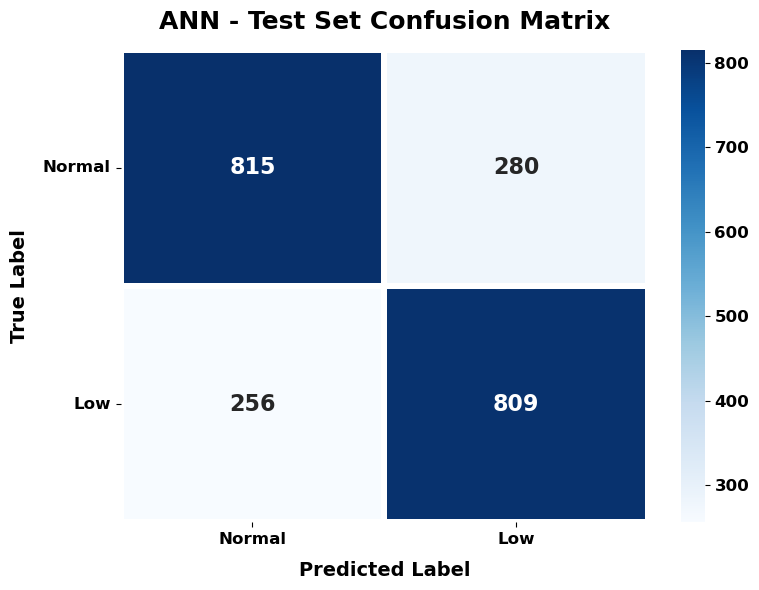


Classification Report:

              precision    recall  f1-score   support

      Normal      0.761     0.744     0.753      1095
         Low      0.743     0.760     0.751      1065

    accuracy                          0.752      2160
   macro avg      0.752     0.752     0.752      2160
weighted avg      0.752     0.752     0.752      2160



In [ ]:
# Confusion matrix hesapla
cm = confusion_matrix(y_test, y_pred)
class_names = ["Normal", "Low"]

# Görsel boyutu
plt.figure(figsize=(8, 6))

# Seaborn ile Confusion Matrix çizimi
ax = sns.heatmap(
    cm,
    annot=True,          # Hücre içine sayı yaz
    fmt='d',             # Tam sayı formatı
    cmap='Blues',        # Renk paleti
    linewidths=3,        # Kare arası çizgi kalınlığı
    linecolor='white',   # Çizgi rengi
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 16, "weight": "bold"},
    cbar=True)

# Başlık ve eksen etiketleri
plt.title("ANN - Test Set Confusion Matrix", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel("True Label", fontsize=14, fontweight='bold', labelpad=10)

# Tick etiketleri biçimi
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Colorbar (sağdaki skala) yazı boyutunu büyüt
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

# Çerçeveyi sıkı yerleştir
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_ann.png", dpi=600, bbox_inches="tight")

# Göster
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

#### ROC Curve (Receiver Operating Characteristic)

In [ ]:
# Tahmin edilen olasılıklar
y_proba = best_model.predict(X_test).ravel()

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step


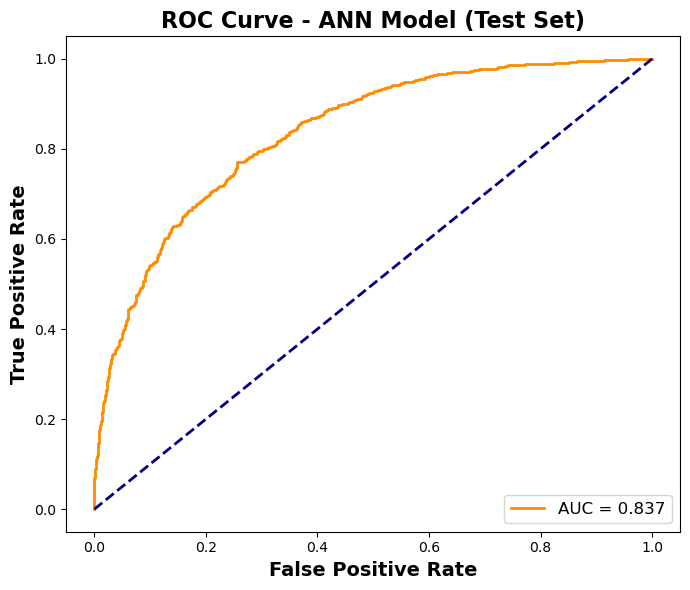

In [ ]:
# ROC eğrisi çizimi
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate", fontsize=14, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=14, fontweight='bold')
plt.title("ROC Curve - ANN Model (Test Set)", fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig("roc_curve_ann_test.png", dpi=600, bbox_inches="tight")
plt.show()

#### Precision–Recall Curve (PR Curve)

In [ ]:
# Precision, Recall ve threshold değerlerini hesapla
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)

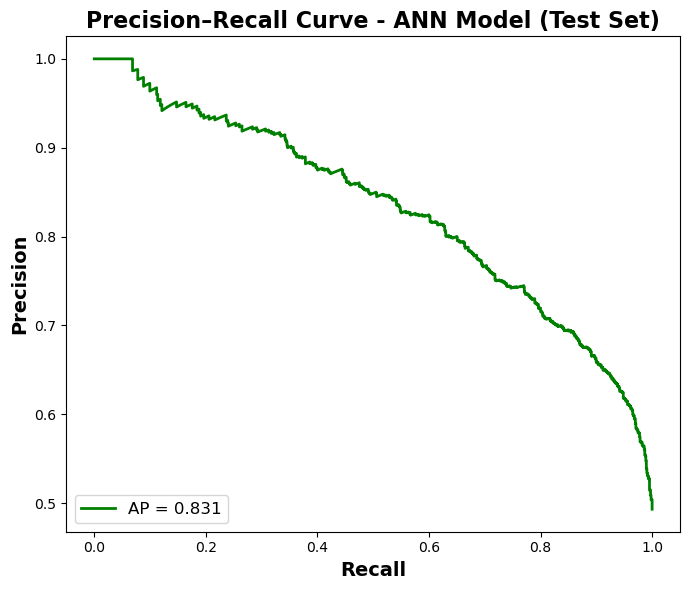

In [ ]:
# PR eğrisi
plt.figure(figsize=(7,6))
plt.plot(recall, precision, color='green', lw=2, label=f"AP = {average_precision:.3f}")
plt.xlabel("Recall", fontsize=14, fontweight='bold')
plt.ylabel("Precision", fontsize=14, fontweight='bold')
plt.title("Precision–Recall Curve - ANN Model (Test Set)", fontsize=16, fontweight='bold')
plt.legend(loc="lower left", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig("pr_curve_ann_test.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# DataFrame oluştur
df_roc = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr,
    'Thresholds_ROC': thresholds_roc
})

df_pr = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
})

# Excel’e kaydet (tek dosyada iki sayfa)
with pd.ExcelWriter('ANN_ROC_PR_curves.xlsx') as writer:
    df_roc.to_excel(writer, sheet_name='ROC', index=False)
    df_pr.to_excel(writer, sheet_name='PR', index=False)

print("✅ ROC ve PR verileri Excel'e kaydedildi: ANN_ROC_PR_curves.xlsx")

✅ ROC ve PR verileri Excel'e kaydedildi: ANN_ROC_PR_curves.xlsx


#### Train Set

In [ ]:
# Train veri setinde tahminler
y_train_proba = best_model.predict(X_train).ravel()

# Tahminleri 0 veya 1'e çevirme (eşik = 0.5)
y_train_pred = (y_train_proba > 0.5).astype(int)

158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step


In [ ]:
# Sonuclarin Train Veri Setinde Degerlendirilmesi
print("*********** ANN - Train Set ***********")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))
print("AUC Score:", roc_auc_score(y_train, y_train_proba))

*********** ANN - Train Set ***********
Accuracy: 0.7626984126984127
Precision: 0.7626520204001569
Recall: 0.7668639053254438
F1 Score: 0.7647521636506688
AUC Score: 0.847993480494632


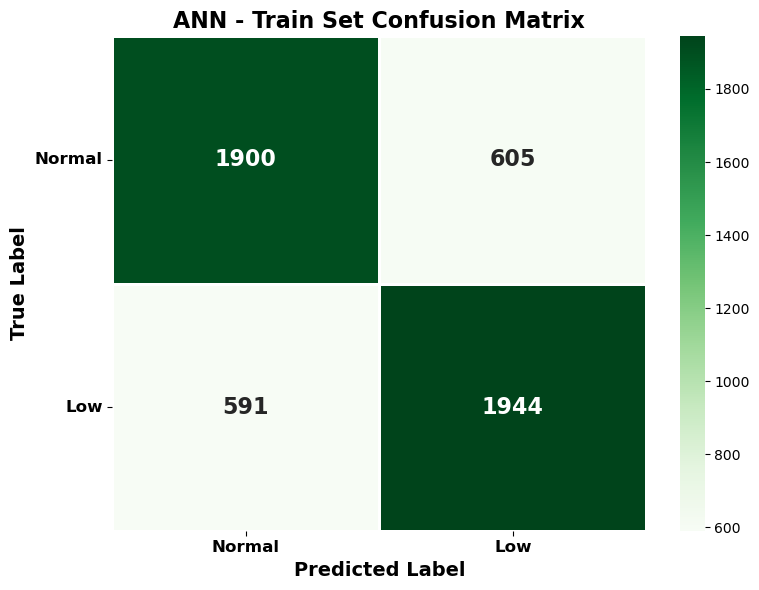


Classification Report (Train Set):

              precision    recall  f1-score   support

      Normal      0.763     0.758     0.761      2505
         Low      0.763     0.767     0.765      2535

    accuracy                          0.763      5040
   macro avg      0.763     0.763     0.763      5040
weighted avg      0.763     0.763     0.763      5040



In [ ]:
# Confusion matrix hesapla
cm_train = confusion_matrix(y_train, y_train_pred)
class_names = ["Normal", "Low"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_train,
            annot=True,
            fmt='d',
            cmap='Greens',        # Train set için farklı renk paleti (isteğe bağlı)
            linewidths=2,
            linecolor='white',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 16, "weight": "bold"},
            cbar=True)

plt.title("ANN - Train Set Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold', rotation=0)
plt.tight_layout()

# 600 dpi olarak kaydet
plt.savefig("confusion_matrix_ann_train.png", dpi=600, bbox_inches="tight")
plt.show()

# Classification report
print("\nClassification Report (Train Set):\n")
print(classification_report(y_train, y_train_pred, target_names=class_names, digits=3))

#### Train Set (5-fold CV)

In [ ]:
random.seed(17)
np.random.seed(17)
tf.random.set_seed(17)

# NumPy dönüştürmeleri
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

# K-Fold ayarı
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

# En iyi modeli seç
ann_model = random_search_tuner.get_best_models(num_models=1)[0]
#ann_model = load_model('ferritin_prediction_binary_classification.keras')

# Modelin başlangıç ağırlıklarını kaydet
initial_weights = ann_model.get_weights()

# Metrikler için boş listeler
cv_acc_scores = []
cv_prec_scores = []
cv_rec_scores = []
cv_f1_scores = []
cv_auc_scores = []

# K-Fold uygulama
for train_ix, test_ix in kfold.split(X_train, y_train):

    # Veriyi train/test olarak ayırma
    X_train_n, X_test_n = X_train[train_ix], X_train[test_ix]
    y_train_n, y_test_n = y_train[train_ix], y_train[test_ix]

    # Her fold için modelin ağırlıklarını sıfırlama (başlangıç ağırlıklarına döndür)
    ann_model.set_weights(initial_weights)

    # Modeli her fold için yeniden eğit
    ann_model.fit(X_train_n, y_train_n, epochs=25, batch_size=32, verbose=0)

    # Olasılık tahmini (pozitif sınıf)
    y_proba = ann_model.predict(X_test_n, verbose=0).ravel()

    # Etiket tahmini (eşik 0.5)
    y_pred = (y_proba >= 0.5).astype(int)

    # Performans metriklerini hesapla
    acc_score = accuracy_score(y_test_n, y_pred)  # accuracy
    pre_score = precision_score(y_test_n, y_pred)  # precision
    rec_score = recall_score(y_test_n, y_pred)  # recall
    f1_score_ = f1_score(y_test_n, y_pred) # f1 score
    auc_score = roc_auc_score(y_test_n, y_proba) #AUC scoore

    # Sonuçları kaydet
    cv_acc_scores.append(acc_score)
    cv_prec_scores.append(pre_score)
    cv_rec_scores.append(rec_score)
    cv_f1_scores.append(f1_score_)
    cv_auc_scores.append(auc_score)

# 5 fold sonuçlarının ortalamalarını ve standart sapmalarını hesapla
print("*********** ANN - Train Set (5-fold CV) ***********")
print("Accuracy: {} \tStd: {}".format(np.mean(cv_acc_scores), np.std(cv_acc_scores)))
print("Precision:{} \tStd: {}".format(np.mean(cv_prec_scores), np.std(cv_prec_scores)))
print("Recall:   {} \tStd: {}".format(np.mean(cv_rec_scores), np.std(cv_rec_scores)))
print("F1 :      {} \tStd: {}".format(np.mean(cv_f1_scores), np.std(cv_f1_scores)))
print("ROC AUC   {} \tStd: {}".format(np.mean(cv_auc_scores), np.std(cv_auc_scores)))

*********** ANN - Train Set (5-fold CV) ***********
Accuracy: 0.7589285714285714 	Std: 0.0132506411564
Precision:0.7499404451483104 	Std: 0.019322278399173182
Recall:   0.7822485207100591 	Std: 0.003658232148124557
F1 :      0.7656157012180869 	Std: 0.009881664800230975
ROC AUC   0.842680713523643 	Std: 0.012377905001265262


In [ ]:
print("Accuracy per fold:", cv_acc_scores)
print("Precision per fold:", cv_prec_scores)
print("Recall per fold:", cv_rec_scores)
print("F1 per fold:", cv_f1_scores)
print("ROC AUC per fold:", cv_auc_scores)

Accuracy per fold: [0.7797619047619048, 0.753968253968254, 0.7400793650793651, 0.7658730158730159, 0.7549603174603174]
Precision per fold: [0.7821782178217822, 0.7429643527204502, 0.7231329690346083, 0.7561436672967864, 0.7452830188679245]
Recall per fold: [0.7790927021696252, 0.7810650887573964, 0.7830374753451677, 0.7889546351084813, 0.7790927021696252]
F1 per fold: [0.7806324110671937, 0.7615384615384615, 0.7518939393939394, 0.7722007722007722, 0.7618129218900676]
ROC AUC per fold: [0.8550000590534906, 0.8462640793363962, 0.8212647682937873, 0.8374493616317662, 0.8534252993027751]
